# Introdução

O presente trabalho tem como objetivo desenvolver um modelo de classificação utilizando técnicas de Machine Learning para prever a presença de diabetes a partir de informações clínicas dos pacientes. Para isso, foi utilizado o conjunto de dados **Pima Indians Diabetes Database**, disponibilizado publicamente na plataforma Kaggle.

O diabetes mellitus é uma doença metabólica crônica caracterizada pela elevação dos níveis de Glucose no sangue, decorrente da produção insuficiente de Insulin pelo organismo ou da resistência das células a sua ação. Segundo a Organização Mundial da Saúde (OMS), o diabetes representa um dos principais problemas de saúde pública da atualidade, estando associado ao aumento do risco de complicações cardiovasculares, renais, neurológicas e oftalmológicas quando não diagnosticado e tratado precocemente.

Nesse contexto, técnicas de Inteligência Artificial e Machine Learning têm sido amplamente utilizadas como ferramentas de apoio à decisão clínica, permitindo identificar padrões em dados médicos e auxiliar na estimativa do risco de desenvolvimento de determinadas doenças. Embora esses modelos não substituam a avaliação realizada por profissionais da saúde, eles podem contribuir para o diagnóstico precoce e para a tomada de decisões mais rápidas e fundamentadas.

Neste projeto será desenvolvido e avaliado três modelo de classificação capaz de prever a presença de diabetes com base em informações clínicas e laboratoriais dos pacientes. Ao longo do trabalho serão apresentadas todas as etapas do processo de Ciência de Dados, incluindo análise exploratória, pré-processamento dos dados, construção e otimização dos modelos, avaliação de desempenho e interpretação dos resultados por meio de técnicas de Inteligência Artificial Explicável.


# Objetivo Geral

Desenvolver e comparar modelos de Machine Learning capazes de classificar pacientes quanto à presença ou ausência de diabetes utilizando dados clínicos estruturados, selecionando o modelo com melhor desempenho para o problema proposto.

## Objetivos Específicos

* Compreender o problema de negócio e as características do conjunto de dados.
* Realizar a análise exploratória e o pré-processamento dos dados.
* Tratar os valores ausentes utilizando a técnica KNNImputer.
* Construir modelos de classificação utilizando Regressão Logística, Random Forest e Gradient Boosting.
* Otimizar os hiperparâmetros dos modelos por meio do GridSearchCV.
* Avaliar o desempenho dos modelos utilizando validação cruzada e métricas como Accuracy, Precision, Recall, F1-score e ROC-AUC.
* Selecionar o modelo mais adequado para o problema estudado.
* Interpretar o modelo final utilizando técnicas de Inteligência Artificial Explicável, como Feature Importance e SHAP.


#Entendimento do problema

O crescimento do volume de exames médicos e prontuários eletrônicos torna cada vez mais desafiadora a realização de diagnósticos rápidos e precisos. Nesse contexto, técnicas de Inteligência Artificial podem atuar como ferramentas de apoio ao médico, auxiliando na identificação precoce de pacientes com maior probabilidade de desenvolver determinadas doenças.

Neste trabalho, o problema consiste em construir um modelo de classificação binária capaz de prever se uma paciente apresenta ou não diabetes, utilizando apenas informações clínicas disponíveis em exames laboratoriais e características pessoais.

A variável alvo (Outcome) possui dois valores possíveis:
- 0: paciente sem diabetes;
- 1: paciente com diabetes.

O objetivo do modelo é aprender padrões existentes nos dados para estimar corretamente a probabilidade de um novo paciente pertencer a uma dessas duas classes.

# Descrição do Conjunto de Dados

O conjunto de dados utilizado neste trabalho é o Pima Indians Diabetes Database, disponibilizado na plataforma Kaggle. A base contém informações clínicas e laboratoriais de pacientes do sexo feminino pertencentes à população indígena Pima, sendo amplamente utilizada em estudos de classificação na área de Machine Learning. O objetivo consiste em prever a presença de diabetes a partir de características clínicas dos pacientes.

## Dicionário de Dados

| Variável | Descrição | Unidade |
|-----------|-----------|----------|
| **Pregnancies** | Número de vezes que a paciente engravidou. | Quantidade |
| **Glucose** | Concentração plasmática de Glucose medida 2 horas após o teste oral de tolerância à Glucose (OGTT). | mg/dL |
| **BloodPressure** | Pressão arterial diastólica. | mmHg |
| **SkinThickness** | Espessura da dobra cutânea do tríceps. | mm |
| **Insulin** | Nível sérico de Insulin medido 2 horas após o OGTT. | μU/mL |
| **BMI** | Índice de Massa Corporal (IMC). | kg/m² |
| **DiabetesPedigreeFunction** | Índice que representa a predisposição genética para diabetes. | Índice |
| **Age** | Idade da paciente. | Anos |
| **Outcome** | Variável alvo (0 = Não diabético, 1 = Diabético). | Classe |

#Importação das bibliotecas

In [111]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração dos gráficos
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Pré-processamento
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Divisão da base
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate, GridSearchCV)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)

# Pipeline
from sklearn.pipeline import Pipeline

# Interpretabilidade
import shap

# Teste Qui-quadrado
from scipy.stats import chi2_contingency

#Matriz de Confusão
from sklearn.metrics import ConfusionMatrixDisplay

# Configuração geral
RANDOM_STATE = 42

#Importação da base

In [112]:
df = pd.read_csv('diabetes.csv')

In [113]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [114]:
df.shape

(768, 9)

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


- O dataset possui 768 registros e 9 atributos sendo oito variáveis preditoras e uma variável alvo (Outcome).

#Análise Exploratória dos Dados (EDA)

Como boa prática, nesta etapa não vamos modificar a base. Primeiro entendemos os dados e só depois fazemos a limpeza.

In [116]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


- Com o describe, conseguimos visualizar que algumas colunas com valor igual a zero é incompatível com a fisiologia humana. Será realizado tratamento posteriormente.(Glucose, BloodPressure, SkinThickness, Insulin e BMI).

###Análise dos Histogramas

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

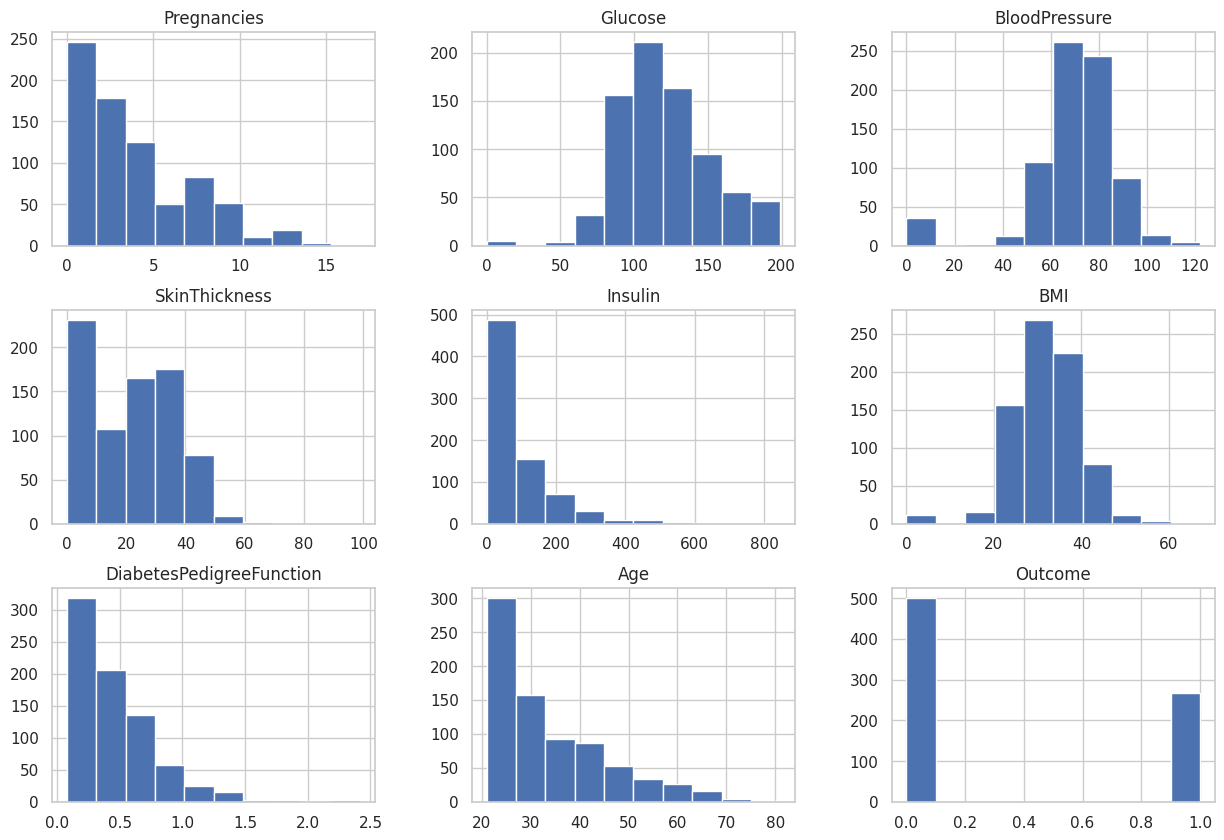

In [117]:
df.hist(figsize=(15,10))

- Observou-se que Glucose, BloodPressure e BMI apresentam distribuições aproximadamente simétricas, enquanto Insulin, DiabetesPedigreeFunction, Age e Pregnancies apresentam assimetria positiva. A variável Insulin destacou-se pela elevada concentração de valores próximos de zero. Além disso, a variável Outcome apresentou desbalanceamento entre as classes.


###Análise dos Boxplots





([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Pregnancies'),
  Text(1, 0, 'Glucose'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'SkinThickness'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'BMI'),
  Text(6, 0, 'DiabetesPedigreeFunction'),
  Text(7, 0, 'Age'),
  Text(8, 0, 'Outcome')])

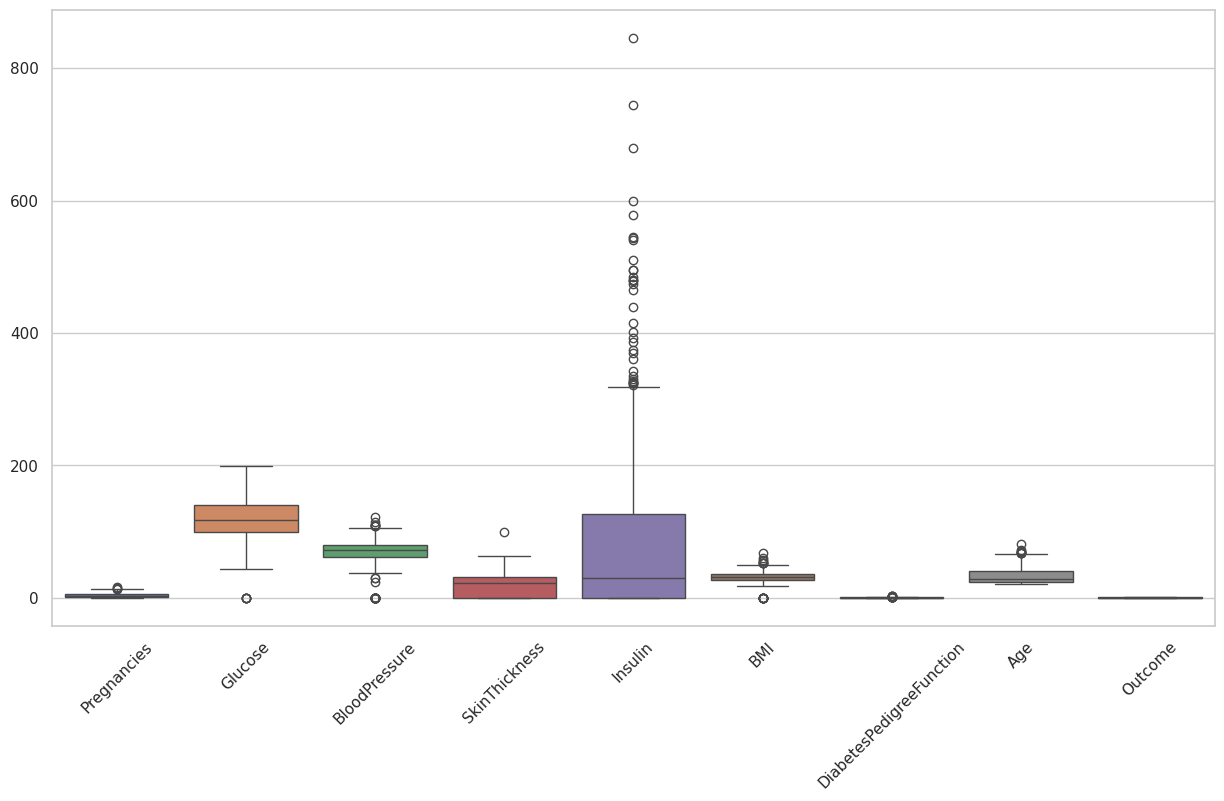

In [118]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)

- Os boxplots evidenciaram a presença de outliers em diversas variáveis, principalmente em Insulin, que apresentou a maior dispersão. Esses valores foram mantidos por poderem representar condições clínicas reais e não necessariamente erros de medição. Já os valores iguais a zero observados em algumas variáveis não foram considerados outliers, mas inconsistências nos dados, por serem fisiologicamente incompatíveis em indivíduos vivos.

#Pré-processamento dos Dados

- Nesta etapa serão realizados os procedimentos de pré-processamento dos dados, com o objetivo de corrigir inconsistências, tratar valores ausentes e preparar o conjunto de dados para o treinamento dos modelos de Machine Learning.

###Conversão de valores inconsistentes para valores ausentes

In [119]:
colunas_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[colunas_missing] = df[colunas_missing].replace(0, np.nan)


- As variáveis definidas acima apresentam registros com valor igual a zero, condição considerada fisiologicamente incompatível em indivíduos vivos. Dessa forma, esses valores foram interpretados como dados ausentes e convertidos para NaN.

###Quantificação dos valores ausentes

In [120]:
pd.DataFrame({
    "Qtd Ausentes": df.isna().sum(),
    "% Ausentes": round(df.isna().mean()*100,2)
}).sort_values("% Ausentes", ascending=False)


,Qtd Ausentes,% Ausentes
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65
Pregnancies,0,0.00
DiabetesPedigreeFunction,0,0.00
Age,0,0.00
Outcome,0,0.00


- Observa-se que as variáveis Insulin e SkinThickness apresentam os maiores percentuais de valores ausentes, seguidas por BloodPressure, BMI e Glucose. Essas informações reforçam a necessidade da etapa de imputação.


#Separação dos dados

Nesta etapa, o conjunto de dados é dividido em treinamento e teste. O conjunto de treinamento será utilizado para desenvolver os modelos, enquanto o conjunto de teste será reservado para avaliar seu desempenho em dados não utilizados durante o treinamento.

In [121]:
X = df.drop(columns = 'Outcome')
y = df['Outcome']

- Divisão do conjunto de dados em variáveis preditoras (X) e variável alvo (y).

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

- O conjunto de dados foi dividido em 80% para treinamento e 20% para teste. Utilizou-se stratify=y para preservar a proporção entre as classes e random_state para garantir a reprodutibilidade dos resultados.

In [123]:
print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

print("\nDistribuição da variável alvo (Treino):")
print(y_train.value_counts(normalize=True))

print("\nDistribuição da variável alvo (Teste):")
print(y_test.value_counts(normalize=True))

Treino: (614, 8)
Teste: (154, 8)

Distribuição da variável alvo (Treino):
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Distribuição da variável alvo (Teste):
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


- Confirmação que a amostragem estratificada foi realizada corretamente.

#Construção dos Pipelines (pré-processamento + modelo)

Nesta etapa serão construídos três modelos supervisionados de classificação utilizando o objeto Pipeline do Scikit-Learn. O Pipeline integra as etapas de imputação dos valores ausentes, padronização das variáveis e treinamento dos modelos, garantindo um fluxo de processamento organizado e evitando vazamento de dados (data leakage).



In [124]:
pipeline_regressao = Pipeline([("imputer", KNNImputer(n_neighbors=5)), ("scaler", StandardScaler()), ("model", LogisticRegression(random_state=RANDOM_STATE))])
pipeline_random = Pipeline([("imputer", KNNImputer(n_neighbors=5)), ("scaler", StandardScaler()), ("model", RandomForestClassifier(random_state=RANDOM_STATE))])
pipeline_gradient = Pipeline([("imputer", KNNImputer(n_neighbors=5)), ("scaler", StandardScaler()), ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))])

modelos = {
    "Logistic Regression": pipeline_regressao,
    "Random Forest": pipeline_random,
    "Gradient Boosting": pipeline_gradient
}


- Foram construídos três pipelines independentes, um para cada algoritmo de classificação avaliado. Cada pipeline integra as etapas de imputação dos valores ausentes, padronização das variáveis e treinamento do respectivo modelo.

#Validação Cruzada

Os modelos foram avaliados utilizando Validação Cruzada Estratificada (5-Fold Cross Validation), proporcionando uma estimativa mais robusta do desempenho e reduzindo a influência do acaso na avaliação.

In [125]:
validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

- Foi utilizada a estratégia Stratified K-Fold com cinco partições, preservando a proporção entre as classes em cada divisão dos dados.

In [126]:
metricas = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

- Para avaliar o desempenho dos modelos foram utilizadas as métricas Accuracy, Precision, Recall, F1-score e ROC-AUC.

In [127]:
resultados = []
for nome, modelo in modelos.items():
    scores = cross_validate(estimator=modelo, X=X_train, y=y_train, cv=validacao_cruzada, scoring=metricas, return_train_score=False)
    resultados.append({
        "Modelo": nome,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC AUC": scores["test_roc_auc"].mean()
    })


- Cada modelo foi submetido à validação cruzada utilizando as métricas definidas anteriormente. Os resultados correspondem à média obtida nas cinco partições.

In [128]:
pd.DataFrame(resultados).sort_values(by="ROC AUC", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.789871,0.760843,0.588926,0.661187,0.841679
1,Random Forest,0.757324,0.685041,0.574751,0.623311,0.824455
2,Gradient Boosting,0.749180,0.658224,0.593577,0.623133,0.810278


- A tabela apresenta o desempenho médio de cada modelo durante a validação cruzada, permitindo uma comparação inicial antes da etapa de otimização dos hiperparâmetros.

#Otimização dos Hiperparâmetros

Nesta etapa, será utilizado o Grid Search com validação cruzada para identificar a melhor combinação de hiperparâmetros de cada modelo. A otimização será baseada na métrica ROC-AUC, por sua capacidade de avaliar o desempenho em problemas de classificação binária.

In [129]:
print('-----------Random Forest----------------')

param_grid_random = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_random = GridSearchCV(estimator=pipeline_random, param_grid=param_grid_random, scoring="roc_auc", cv=validacao_cruzada, n_jobs=-1, verbose=1)
grid_random.fit(X_train, y_train)

print('-----------Gradient Boosting----------------')

param_grid_gradient = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

grid_gradient = GridSearchCV(estimator=pipeline_gradient, param_grid=param_grid_gradient, scoring="roc_auc", cv=validacao_cruzada, n_jobs=-1, verbose=1)
grid_gradient.fit(X_train, y_train)

print('-----------Regressão Logística----------------')

param_grid_regressao = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"],
    "model__max_iter": [500, 1000]
}
grid_regressao = GridSearchCV(estimator=pipeline_regressao, param_grid=param_grid_regressao, scoring="roc_auc", cv=validacao_cruzada, n_jobs=-1, verbose=1)
grid_regressao.fit(X_train, y_train)


-----------Random Forest----------------
Fitting 5 folds for each of 108 candidates, totalling 540 fits
-----------Gradient Boosting----------------
Fitting 5 folds for each of 18 candidates, totalling 90 fits
-----------Regressão Logística----------------
Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('imputer', KNNImputer()),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__max_iter': [500, 1000],
                         'model__penalty': ['l2'],
                         'model__solver': ['lbfgs', 'liblinear']},
             scoring='roc_auc', verbose=1)

- O Grid Search foi aplicado individualmente a cada modelo, avaliando diferentes combinações de hiperparâmetros por meio de validação cruzada estratificada. Para cada algoritmo, foi selecionada automaticamente a configuração que apresentou o maior valor de ROC-AUC.


***Visualização de qual modelo teve o melhor desempenho após otimização***

In [130]:
resultados = pd.DataFrame(resultados)
comparacao = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "ROC-AUC (Padrão)": [
        resultados.loc[resultados["Modelo"] == "Logistic Regression", "ROC AUC"].iloc[0],
        resultados.loc[resultados["Modelo"] == "Random Forest", "ROC AUC"].iloc[0],
        resultados.loc[resultados["Modelo"] == "Gradient Boosting", "ROC AUC"].iloc[0],
    ],

    "ROC-AUC (Otimizado)": [
        grid_regressao.best_score_,
        grid_random.best_score_,
        grid_gradient.best_score_
    ]

})

comparacao

,Modelo,ROC-AUC (Padrão),ROC-AUC (Otimizado)
0,Logistic Regression,0.841679,0.843241
1,Random Forest,0.824455,0.838733
2,Gradient Boosting,0.810278,0.830779


- A comparação entre os modelos antes e após a otimização mostra que todos apresentaram melhoria no desempenho, evidenciando a importância do ajuste de hiperparâmetros. Apesar de o Gradient Boosting ter obtido o maior ganho relativo, a Regressão Logística permaneceu com o maior valor de ROC-AUC, sendo o modelo de melhor desempenho durante a validação cruzada.

#Avaliação Final dos Modelos

Após a otimização dos hiperparâmetros, os modelos foram avaliados utilizando o conjunto de teste, mantido isolado durante todo o desenvolvimento. O desempenho foi analisado por meio das métricas Accuracy, Precision, Recall, F1-Score e ROC-AUC, além da matriz de confusão para identificar os tipos de erros de classificação.

In [131]:
pred_regressao = grid_regressao.predict(X_test)
prob_regressao = grid_regressao.predict_proba(X_test)[:,1]

pred_random = grid_random.predict(X_test)
prob_random = grid_random.predict_proba(X_test)[:,1]

pred_gradient = grid_gradient.predict(X_test)
prob_gradient = grid_gradient.predict_proba(X_test)[:,1]

- Nesta etapa, são obtidas as classes previstas (predict) e as probabilidades de cada paciente pertencer à classe positiva (predict_proba). Essas informações serão utilizadas no cálculo das métricas de desempenho e da curva ROC.

In [132]:
def avaliar_modelo(nome, y_true, pred, prob):
    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, prob)
    }

- Para evitar repetição de código, foi criada uma função responsável por calcular as principais métricas de desempenho de cada modelo.

In [133]:
resultados_teste = []
resultados_teste.append(avaliar_modelo("Logistic Regression", y_test, pred_regressao, prob_regressao))
resultados_teste.append(avaliar_modelo("Random Forest", y_test, pred_random, prob_random))
resultados_teste.append(avaliar_modelo("Gradient Boosting", y_test, pred_gradient, prob_gradient))

resultados_teste = pd.DataFrame(resultados_teste)
resultados_teste

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.694805,0.571429,0.518519,0.543689,0.814074
1,Random Forest,0.707792,0.595745,0.518519,0.554455,0.809815
2,Gradient Boosting,0.714286,0.613636,0.500000,0.551020,0.810648


- Os resultados mostram que não existe um modelo superior em todas as métricas. O Gradient Boosting apresentou a maior Accuracy e Precision, enquanto o Random Forest obteve o melhor F1-Score. Já a Regressão Logística alcançou o maior valor de ROC-AUC, indicando melhor capacidade de discriminar pacientes diabéticos e não diabéticos. Considerando que a ROC-AUC foi a métrica adotada para otimização e comparação dos modelos, a Regressão Logística apresentou o melhor desempenho geral.

#Avaliação Clínica dos Modelos

Além das métricas de desempenho, as matrizes de confusão foram analisadas para identificar os tipos de erros cometidos pelos modelos. Em aplicações médicas, essa avaliação é importante para compreender o impacto dos falsos positivos e dos falsos negativos.

###Curvas ROC

In [134]:
def plotar_curvas_roc(modelos, X_test, y_test, titulo="Comparação das Curvas ROC"):
    plt.figure(figsize=(8, 6))

    for modelo, nome in modelos:
        RocCurveDisplay.from_estimator(
            modelo,
            X_test,
            y_test,
            name=nome
        )

    plt.plot([0, 1], [0, 1], "k--", label="Aleatório")
    plt.title(titulo)
    plt.legend()
    plt.show()

<Figure size 800x600 with 0 Axes>

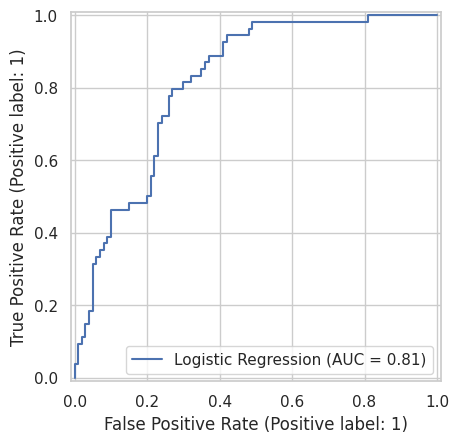

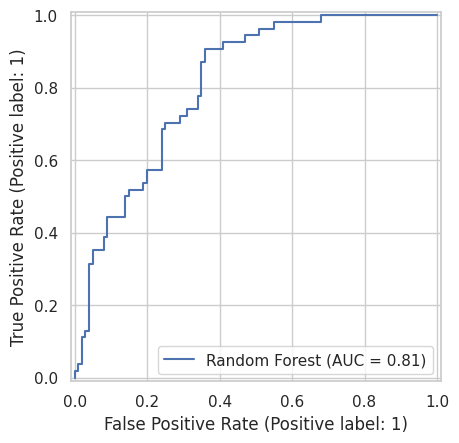

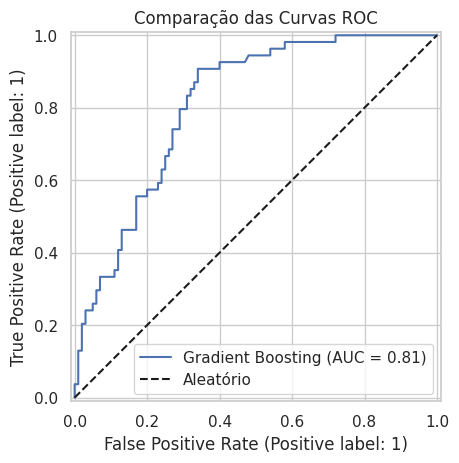

In [135]:
modelos = [
    (grid_regressao, "Logistic Regression"),
    (grid_random, "Random Forest"),
    (grid_gradient, "Gradient Boosting")
]

plotar_curvas_roc(modelos, X_test, y_test)

- A Curva ROC demonstra a relação entre a taxa de verdadeiros positivos (sensibilidade) e a taxa de falsos positivos para diferentes limiares de classificação. Quanto mais próxima a curva estiver do canto superior esquerdo e maior for a área sob a curva (ROC-AUC), melhor é a capacidade do modelo em distinguir pacientes diabéticos e não diabéticos. Neste estudo, a Regressão Logística apresentou a maior ROC-AUC (0,814), indicando o melhor desempenho discriminatório entre os modelos avaliados, embora as diferenças em relação ao Random Forest e ao Gradient Boosting tenham sido pequenas.

###Matriz de Confusão

In [136]:
def plotar_matriz(modelo, X, y, titulo):
    ConfusionMatrixDisplay.from_estimator(modelo, X, y, cmap="Blues", values_format="d")
    plt.title(titulo)
    plt.show()

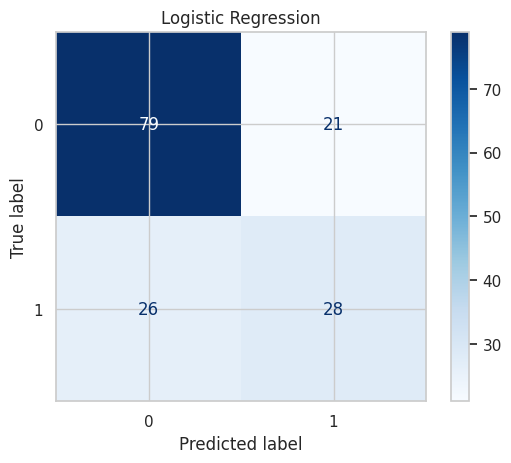

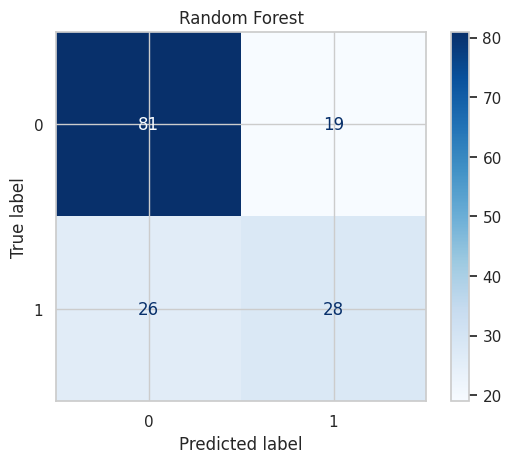

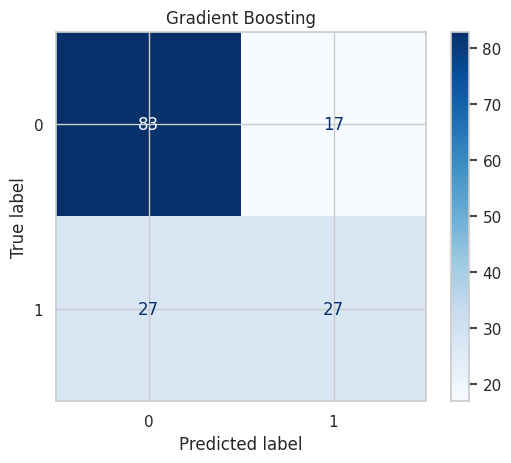

In [137]:
plotar_matriz(grid_regressao, X_test, y_test, "Logistic Regression")
plotar_matriz(grid_random, X_test, y_test, "Random Forest")
plotar_matriz(grid_gradient, X_test, y_test, "Gradient Boosting")

- Comparando as matrizes de confusão, observa-se que os três modelos apresentaram comportamento semelhante na identificação de pacientes não diabéticos, com maior número de verdadeiros negativos. Em relação aos pacientes diabéticos, o Random Forest e a Regressão Logística obtiveram maior quantidade de verdadeiros positivos, enquanto o Gradient Boosting apresentou um número ligeiramente maior de falsos negativos. Considerando o contexto clínico, a redução de falsos negativos é especialmente importante, pois representa pacientes com diabetes que poderiam deixar de ser identificados pelo modelo.

#Interpretabilidade do Modelo

Nesta etapa, serão utilizadas técnicas de interpretabilidade para compreender como o modelo realiza suas previsões, identificando os atributos que mais influenciam a classificação dos pacientes.

In [138]:
lr = grid_regressao.best_estimator_.named_steps["model"]

- Recupera a Regressão Logística otimizada do Pipeline

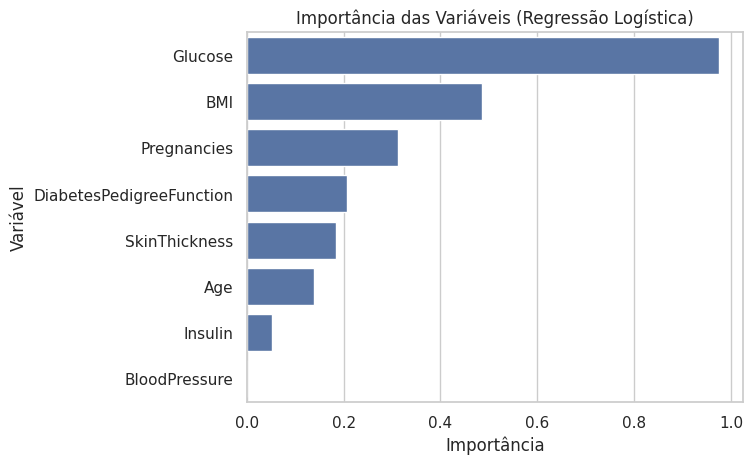

In [139]:
importancias = pd.DataFrame({
    "Variável": X_train.columns,
    "Coeficiente": lr.coef_[0],
    "Importância": np.abs(lr.coef_[0])
}).sort_values(by="Importância", ascending=False)
sns.barplot(data=importancias, x="Importância", y="Variável")
plt.title("Importância das Variáveis (Regressão Logística)")
plt.show()

- O gráfico apresenta a importância das variáveis calculada a partir do valor absoluto dos coeficientes da Regressão Logística. Observa-se que a Glucose foi o atributo de maior influência nas previsões, seguida por BMI, Pregnancies. Em contrapartida, pressão arterial e insulina apresentaram baixa contribuição para a classificação realizada pelo modelo.

***SHAP***

Explicação de por que um paciente específico foi classificado como diabético.

In [140]:
X_train_transformado = grid_regressao.best_estimator_[:-1].transform(X_train)
X_train_transformado = pd.DataFrame(X_train_transformado, columns=X_train.columns)

- Nesta etapa, o pipeline otimizado é utilizado para aplicar as transformações de pré-processamento ao conjunto de treinamento. Como o método transform() retorna um numpy.ndarray, os dados são convertidos novamente para um DataFrame, preservando os nomes das variáveis para facilitar a interpretação e a geração dos gráficos SHAP.

In [141]:
explicador = shap.Explainer(lr, X_train_transformado)
shap_values = explicador(X_train_transformado)

- Nesta etapa, é criado o explicador SHAP para a Regressão Logística utilizando os dados já pré-processados. Em seguida, são calculados os valores SHAP, que quantificam a contribuição de cada variável para as previsões do modelo, permitindo analisar sua importância e interpretar as decisões de forma global e individual.

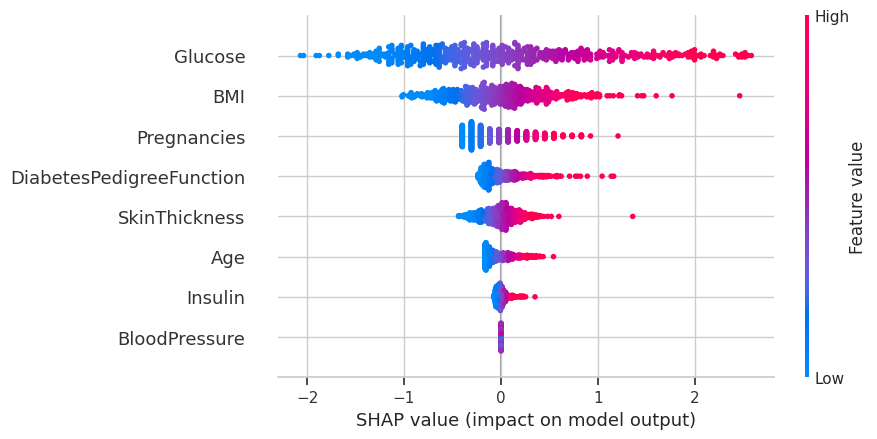

In [142]:
shap.plots.beeswarm(shap_values)

- O gráfico SHAP mostra que Glucose foi a variável de maior impacto nas previsões do modelo, seguida por BMI, Pregnancies e DiabetesPedigreeFunction. Os pontos vermelhos representam valores elevados da variável, enquanto os azuis representam valores baixos. Valores altos de Glucose e BMI tendem a aumentar a probabilidade de classificação como diabetes, enquanto valores menores contribuem para reduzir essa probabilidade.

### Análise Verdadeiro Positivo

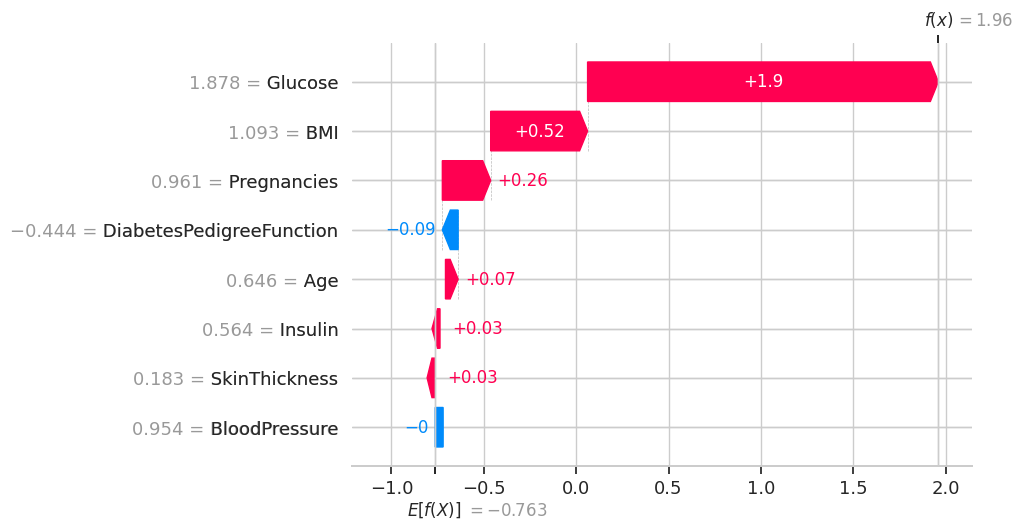

In [143]:
indice = np.where((y_test == 1) & (pred_regressao == 1))[0][0]
shap.plots.waterfall(shap_values[indice])

- O gráfico Waterfall apresenta a explicação individual da previsão realizada para um paciente corretamente classificado como diabético. A previsão parte do valor médio do modelo (E[f(X)] = -0,763) e, após considerar as características do paciente, atinge o valor final (f(x) = 1,96), indicando forte evidência para a classificação como diabetes.

- Observa-se que a variável Glucose foi a principal responsável pela decisão do modelo, contribuindo positivamente em aproximadamente +1,90. Em seguida, BMI (+0,52) e Pregnancies (+0,26) também exerceram influência significativa no aumento da probabilidade de diabetes. Por outro lado, DiabetesPedigreeFunction apresentou pequena contribuição negativa (-0,09), reduzindo ligeiramente a previsão. As demais variáveis (Age, Insulin, SkinThickness e BloodPressure) tiveram impacto reduzido na decisão final.

- Esse resultado demonstra que o modelo fundamentou sua decisão principalmente em níveis elevados de Glucose, complementados pelo BMI e pelo número de gestações, fatores reconhecidos na literatura como importantes indicadores para o diagnóstico do diabetes.

### Análise Falso Negativo

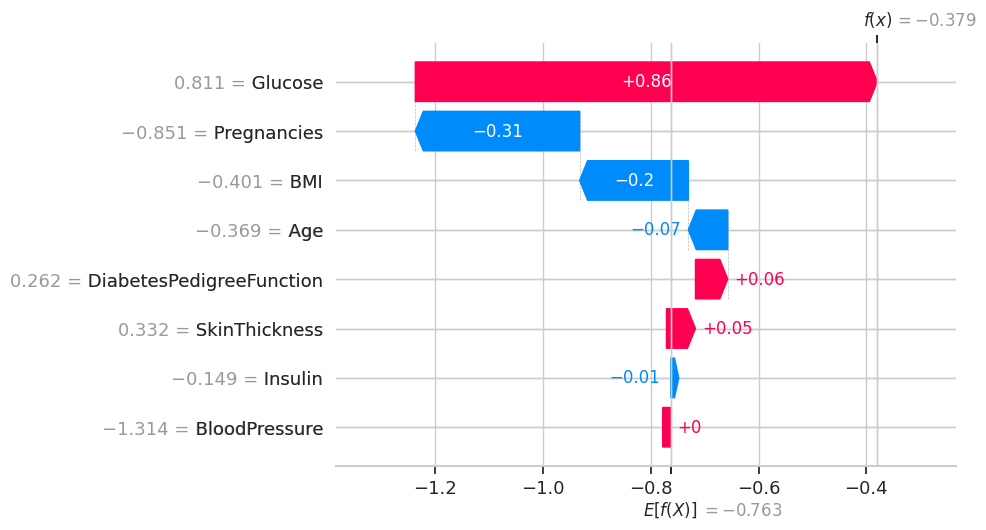

In [144]:
indice = np.where((y_test == 1) & (pred_regressao == 0))[0][0]
shap.plots.waterfall(shap_values[indice])

- Este gráfico explica por que a Regressão Logística deixou de identificar um paciente que realmente possui diabetes.

- A previsão parte do valor médio do modelo (E[f(X)] = -0,763) e termina em f(x) = -0,379. Embora algumas características indiquem maior risco de diabetes, a soma das contribuições permaneceu abaixo do limiar de decisão do modelo, resultando na classificação incorreta como não diabético.

- Observa-se que Glucose foi a variável que mais aumentou a probabilidade de diabetes, contribuindo positivamente em aproximadamente +0,86. Entretanto, esse efeito foi compensado principalmente pelos baixos valores de Pregnancies (-0,31), BMI (-0,20) e Age (-0,07), que reduziram a saída do modelo. As demais variáveis exerceram influência pequena na decisão final.

- Esse resultado mostra que, apesar da Glucose indicar um risco elevado, o conjunto das demais características levou o modelo a considerar que o paciente apresentava baixa probabilidade de diabetes, ocasionando um falso negativo.

#Discussão dos Resultados

Os três modelos avaliados apresentaram desempenho satisfatório na classificação de pacientes quanto à presença de diabetes. Após a otimização dos hiperparâmetros, a Regressão Logística obteve o melhor desempenho geral, alcançando o maior valor de ROC-AUC (0,814), demonstrando maior capacidade de distinguir pacientes diabéticos e não diabéticos.

A análise das métricas mostrou que os três algoritmos apresentaram resultados próximos, porém a Regressão Logística se destacou por combinar melhor capacidade de discriminação das classes com um modelo mais simples e interpretável. Além disso, a utilização do SHAP permitiu compreender de forma transparente como cada variável influenciou as previsões, aspecto especialmente importante em aplicações médicas.

As análises de interpretabilidade indicaram que Glucose foi a variável de maior influência nas decisões do modelo, seguida por BMI, Pregnancies e DiabetesPedigreeFunction. Esses resultados são coerentes com o conhecimento clínico, uma vez que a glicemia é um dos principais indicadores utilizados no diagnóstico do diabetes.

A análise individual por meio do gráfico Waterfall mostrou que o modelo é capaz de explicar cada previsão realizada, evidenciando quais características contribuíram para aumentar ou reduzir a probabilidade de diabetes. Também foi possível analisar um caso de falso negativo, demonstrando que, embora a glicose apresentasse influência positiva, a combinação das demais variáveis levou o modelo a classificar incorretamente um paciente diabético como não diabético. Essa análise evidencia a importância da interpretabilidade para compreender as limitações do modelo.



#Conclusão

Neste trabalho foi desenvolvido um sistema de classificação para auxiliar na identificação de pacientes com diabetes utilizando dados clínicos estruturados. Foram avaliados três algoritmos de Machine Learning — Regressão Logística, Random Forest e Gradient Boosting — desde a exploração dos dados até a interpretação das previsões.

Os resultados demonstraram que a Regressão Logística apresentou o melhor desempenho entre os modelos avaliados, obtendo o maior ROC-AUC após a otimização dos hiperparâmetros. Além do desempenho competitivo, o modelo apresentou elevada capacidade de interpretação por meio da análise dos coeficientes e da técnica SHAP, permitindo compreender quais fatores influenciaram suas decisões.

Embora os resultados sejam promissores, o modelo não deve ser utilizado como ferramenta de diagnóstico definitivo. Sua principal aplicação é atuar como sistema de apoio à decisão clínica, auxiliando profissionais de saúde na triagem inicial e na identificação de pacientes com maior probabilidade de diabetes. A decisão diagnóstica deve permanecer sob responsabilidade do médico, que poderá considerar também exames complementares, histórico clínico e outros fatores não contemplados pelo modelo.